# Router Experiments – Single & Batch, Multi-Mode Evaluation

## Overview

This notebook evaluates the **text-only Artemis VLM Router**. It does **not** deal with the load balancer directly (see load_balancer notebooks for that).

**Focus Areas:**
1. **Single-Request Introspection** – Deep dive into how the router scores each model for specific prompts
2. **Batch Evaluation** – Measure routing accuracy, regret, and model usage on a dataset
3. **Mode Trade-offs** – Compare `accuracy`, `cheap`, `fast`, `balanced` modes

**Key Principle:** This notebook uses **only public router APIs** from `router.public_api`. All complex logic lives in modules, not here.

---


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Dict, Any, Optional
import sys
import time
from pathlib import Path

# Add project root to path
project_root = Path("..").resolve()
print(project_root)
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
    sys.path.append(str(project_root / "artemis_final"))
    


/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/Which_VLM_Router


In [2]:
# ============================================================================
# PUBLIC ROUTER API IMPORTS ONLY
# ============================================================================
from artemis_final.router.public_api import (
    init_router,
    route_request,
    route_batch,
    load_router_from_checkpoint,
    RouterService
)
from artemis_final.common.config_loader import load_global_config
from artemis_final.common.data_utils import (
    load_model_profiles,
    load_eval_split,
    compute_oracle_best_model
)

# Plotting defaults
plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

print("=" * 60)
print("ROUTER EXPERIMENTS NOTEBOOK")
print("=" * 60)
print(f"Using public API from: artemis_final.router.public_api")
print(f"Project root: {project_root}")

ROUTER EXPERIMENTS NOTEBOOK
Using public API from: artemis_final.router.public_api
Project root: /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/Which_VLM_Router


## 2. Load Trained Router & Evaluation Dataset

We load:
1. The trained reward router from checkpoint
2. Evaluation data with ground truth scores per model
3. Model profiling data (cost, latency, accuracy stats)


In [3]:
# Load configuration
config = load_global_config()

print("=== Router Configuration ===")
print(f"  Checkpoint: {config.router.checkpoint_path}")
print(f"  Device: {config.router.device}")

# Initialize global router service
init_router()
print("\n Router service initialized")

# Load profiling data (cost/latency per model)
profiles_df = load_model_profiles()
print("\n=== Model Profiles ===")
if not profiles_df.empty:
    display(profiles_df)
else:
    print("  (No profiling data found)")

# Build lookup maps for cost/latency
cost_map = dict(zip(profiles_df['model_name'], profiles_df['avg_cost_usd'])) if not profiles_df.empty else {}
latency_map = dict(zip(profiles_df['model_name'], profiles_df['avg_latency_ms'])) if not profiles_df.empty else {}
accuracy_map = dict(zip(profiles_df['model_name'], profiles_df['avg_accuracy'])) if not profiles_df.empty else {}

# Load evaluation dataset
eval_df = load_eval_split(split="test", limit=500)
print(f"\n=== Evaluation Dataset ===")
print(f"  Total rows: {len(eval_df)}")
if not eval_df.empty:
    print(f"  Unique samples: {eval_df['sample_id'].nunique()}")
    print(f"  Columns: {list(eval_df.columns[:10])}...")
    print("\nPreview:")
    display(eval_df[['sample_id', 'model_name', 'router_task', 'source_dataset']].head())


=== Router Configuration ===
  Checkpoint: checkpoints/best_multitask_router.pt
  Device: cpu
[INFO] Using default RouterModelConfig
[INFO] Loading model from: /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/Which_VLM_Router/artemis_final/checkpoints/best_multitask_router.pt


Failed to initialize router: 'model_state_dict'



✅ Router service initialized

=== Model Profiles ===


,model_name,avg_latency_ms,avg_cost_usd,avg_accuracy
0,deepseek_ocr,916.447958,0.000028,0.153308
1,gemma_3_27b,4437.971750,0.000053,0.402290
2,qwen2_5_vl_3b,2157.796239,0.000103,0.410146
3,qwen2_5_vl_7b,2460.732163,0.000210,0.480755
4,qwen3_vl_8b_thinking,12205.888694,0.001460,0.490475



=== Evaluation Dataset ===
  Total rows: 2500
  Unique samples: 500
  Columns: ['sample_id', 'run_id', 'source_config', 'source_dataset', 'source_index', 'router_task', 'ground_truth_type', 'data_split', 'prompt_text', 'ground_truth']...

Preview:


,sample_id,model_name,router_task,source_dataset
2,ocrvqa_16_c3ede22d,qwen2_5_vl_7b,document_ocr,cauldron
3,hateful_memes_749_25c37fd3,qwen2_5_vl_7b,meme_classification,cauldron
15,iam_364_1605cc3b,qwen2_5_vl_7b,handwriting_ocr,cauldron
17,aokvqa_816_ec899a23,qwen2_5_vl_7b,knowledge_vqa,cauldron
18,hateful_memes_23_bc1e15b7,qwen2_5_vl_7b,meme_classification,cauldron


## 3. Helper Functions for Evaluation

These are notebook-local utilities for printing and computing metrics.


In [4]:
def pretty_print_example(row: pd.Series) -> None:
    """Print an example in a readable format."""
    print(f"  Prompt: {str(row.get('prompt_text', row.get('prompt', 'N/A')))[:100]}...")
    print(f"  Task: {row.get('router_task', 'unknown')}")
    print(f"  Dataset: {row.get('source_dataset', 'unknown')}")

def compute_oracle_for_sample(sample_rows: pd.DataFrame, acc_col: str = 'is_correct') -> str:
    """Given all model rows for one sample, return oracle best model."""
    if acc_col not in sample_rows.columns:
        for alt in ['utility_accuracy', 'score_exact_match_normalized']:
            if alt in sample_rows.columns:
                acc_col = alt
                break
    if acc_col not in sample_rows.columns:
        return sample_rows.iloc[0]['model_name']  # fallback
    
    # Sort by accuracy desc, cost asc (tie-breaker)
    sorted_rows = sample_rows.sort_values(
        by=[acc_col, 'estimated_cost_usd'], 
        ascending=[False, True]
    )
    return sorted_rows.iloc[0]['model_name']

def summarize_router_result(result: Dict, oracle_model: str, profiles: Dict) -> None:
    """Print detailed router result comparison with oracle."""
    chosen = result['chosen_model']
    rewards = result['rewards']
    mode = result['mode']
    
    print(f"\n  Mode: {mode}")
    print(f"  Router prediction: {chosen}")
    print(f"  Per-model scores:")
    for m, score in sorted(rewards.items(), key=lambda x: -x[1]):
        marker = "" if m == chosen else "  "
        oracle_marker = "(oracle)" if m == oracle_model else ""
        print(f"    {marker} {m:30s}: {score:.4f} {oracle_marker}")
    
    print(f"\n  Oracle best model: {oracle_model}")
    
    is_correct = (chosen == oracle_model)
    if is_correct:
        print("  Result:  Router matches oracle")
    else:
        # Compute regret if we have accuracy info
        chosen_score = rewards.get(chosen, 0)
        oracle_score = rewards.get(oracle_model, 0)
        regret = oracle_score - chosen_score
        print(f"  Result:  Router differs from oracle (regret: {regret:.4f})")

def route_single_example(sample_id: str, eval_df: pd.DataFrame, mode: str) -> Dict:
    """Route a single sample and return results with oracle comparison."""
    sample_rows = eval_df[eval_df['sample_id'] == sample_id]
    if sample_rows.empty:
        print(f"Sample {sample_id} not found")
        return {}
    
    row = sample_rows.iloc[0]
    prompt = str(row.get('prompt_text', row.get('prompt', '')))
    
    # Build metadata
    metadata = {}
    if 'router_task' in row: metadata['router_task'] = row['router_task']
    if 'source_dataset' in row: metadata['source_dataset'] = row['source_dataset']
    
    # Oracle
    oracle_model = compute_oracle_for_sample(sample_rows)
    
    print(f"\n{'='*60}")
    print(f"Single Example – sample_id={sample_id}")
    print("="*60)
    pretty_print_example(row)
    
    # Route
    result = route_request(prompt, mode=mode, metadata=metadata)
    summarize_router_result(result, oracle_model, {})
    
    return {
        'sample_id': sample_id,
        'mode': mode,
        'chosen_model': result['chosen_model'],
        'oracle_model': oracle_model,
        'is_correct': result['chosen_model'] == oracle_model,
        'rewards': result['rewards']
    }

print("Helper functions defined.")


Helper functions defined.


## 4. Single-Request Experiments (Multiple Modes)

We select a few representative examples and inspect how the router behaves across all modes.


In [5]:
# Select diverse examples
if not eval_df.empty:
    unique_samples = eval_df.drop_duplicates(subset=['sample_id'])
    
    # Try to get samples from different tasks
    tasks = unique_samples['router_task'].unique() if 'router_task' in unique_samples.columns else ['unknown']
    
    selected_samples = []
    for task in tasks[:3]:  # Up to 3 different tasks
        task_samples = unique_samples[unique_samples['router_task'] == task] if 'router_task' in unique_samples.columns else unique_samples
        if not task_samples.empty:
            selected_samples.append(task_samples.iloc[0]['sample_id'])
    
    # Add more if needed
    if len(selected_samples) < 3:
        for _, row in unique_samples.head(5).iterrows():
            if row['sample_id'] not in selected_samples:
                selected_samples.append(row['sample_id'])
            if len(selected_samples) >= 5:
                break
    
    print(f"Selected {len(selected_samples)} examples for single-request experiments")
    
    MODES = ["accuracy", "cheap", "fast", "balanced"]
    
    single_results = []
    for sample_id in selected_samples[:3]:  # Limit to 3 for clarity
        for mode in MODES:
            res = route_single_example(sample_id, eval_df, mode)
            if res:
                single_results.append(res)
    
    # Summary table
    if single_results:
        summary_df = pd.DataFrame(single_results)
        print("\n" + "="*60)
        print("SINGLE-REQUEST SUMMARY TABLE")
        print("="*60)
        display(summary_df[['sample_id', 'mode', 'chosen_model', 'oracle_model', 'is_correct']])
else:
    print("No evaluation data available for single-request experiments")


Selected 3 examples for single-request experiments

Single Example – sample_id=ocrvqa_16_c3ede22d
  Prompt: What is the title of this book?
Your answer should be very brief....
  Task: document_ocr
  Dataset: cauldron

  Mode: accuracy
  Router prediction: qwen2_5_vl_7b
  Per-model scores:

  Oracle best model: deepseek_ocr
  Result: ❌ Router differs from oracle (regret: 0.0000)

Single Example – sample_id=ocrvqa_16_c3ede22d
  Prompt: What is the title of this book?
Your answer should be very brief....
  Task: document_ocr
  Dataset: cauldron

  Mode: cheap
  Router prediction: qwen2_5_vl_7b
  Per-model scores:

  Oracle best model: deepseek_ocr
  Result: ❌ Router differs from oracle (regret: 0.0000)

Single Example – sample_id=ocrvqa_16_c3ede22d
  Prompt: What is the title of this book?
Your answer should be very brief....
  Task: document_ocr
  Dataset: cauldron

  Mode: fast
  Router prediction: qwen2_5_vl_7b
  Per-model scores:

  Oracle best model: deepseek_ocr
  Result: ❌ Router 

,sample_id,mode,chosen_model,oracle_model,is_correct
0,ocrvqa_16_c3ede22d,accuracy,qwen2_5_vl_7b,deepseek_ocr,False
1,ocrvqa_16_c3ede22d,cheap,qwen2_5_vl_7b,deepseek_ocr,False
2,ocrvqa_16_c3ede22d,fast,qwen2_5_vl_7b,deepseek_ocr,False
3,ocrvqa_16_c3ede22d,balanced,qwen2_5_vl_7b,deepseek_ocr,False
4,hateful_memes_749_25c37fd3,accuracy,qwen2_5_vl_7b,qwen2_5_vl_3b,False
5,hateful_memes_749_25c37fd3,cheap,qwen2_5_vl_7b,qwen2_5_vl_3b,False
6,hateful_memes_749_25c37fd3,fast,qwen2_5_vl_7b,qwen2_5_vl_3b,False
7,hateful_memes_749_25c37fd3,balanced,qwen2_5_vl_7b,qwen2_5_vl_3b,False
8,iam_364_1605cc3b,accuracy,qwen2_5_vl_7b,qwen2_5_vl_3b,False
9,iam_364_1605cc3b,cheap,qwen2_5_vl_7b,qwen2_5_vl_3b,False


## 5. Batch Experiment – Single Mode ("accuracy")

Evaluate the router on the full evaluation batch for one mode, computing:
- Routing accuracy (vs oracle)
- Regret distribution
- Per-model usage
- Average cost/latency


In [6]:
def evaluate_batch(eval_df: pd.DataFrame, mode: str, profiles_df: pd.DataFrame) -> Dict:
    """
    Evaluate router on batch of samples.
    Returns metrics dictionary.
    """
    if eval_df.empty:
        return {}
    
    # Get unique samples
    sample_ids = eval_df['sample_id'].unique()
    unique_samples = eval_df.drop_duplicates(subset=['sample_id'])
    
    print(f"\nEvaluating {len(sample_ids)} samples in '{mode}' mode...")
    
    # Prepare prompts and metadata
    prompts = []
    metas = []
    oracles = []
    
    for sid in sample_ids:
        sample_rows = eval_df[eval_df['sample_id'] == sid]
        row = sample_rows.iloc[0]
        
        prompt = str(row.get('prompt_text', row.get('prompt', '')))
        prompts.append(prompt)
        
        meta = {}
        if 'router_task' in row: meta['router_task'] = row['router_task']
        if 'source_dataset' in row: meta['source_dataset'] = row['source_dataset']
        metas.append(meta)
        
        oracle = compute_oracle_for_sample(sample_rows)
        oracles.append(oracle)
    
    # Batch route
    start = time.time()
    results = route_batch(prompts, modes=[mode]*len(prompts), metadata_list=metas)
    duration = time.time() - start
    
    # Analyze
    chosen_models = [r['chosen_model'] for r in results]
    
    # Metrics
    correct = sum(1 for c, o in zip(chosen_models, oracles) if c == o)
    accuracy = correct / len(chosen_models) if chosen_models else 0
    
    # Regret (using reward scores)
    regrets = []
    for res, oracle in zip(results, oracles):
        chosen_score = res['rewards'].get(res['chosen_model'], 0)
        oracle_score = res['rewards'].get(oracle, 0)
        regrets.append(oracle_score - chosen_score)
    
    # Cost/latency from profiles
    cost_map = dict(zip(profiles_df['model_name'], profiles_df['avg_cost_usd'])) if not profiles_df.empty else {}
    lat_map = dict(zip(profiles_df['model_name'], profiles_df['avg_latency_ms'])) if not profiles_df.empty else {}
    
    costs = [cost_map.get(m, 0) for m in chosen_models]
    latencies = [lat_map.get(m, 0) for m in chosen_models]
    
    # Model usage
    usage = pd.Series(chosen_models).value_counts()
    
    return {
        'mode': mode,
        'n_samples': len(sample_ids),
        'routing_accuracy': accuracy,
        'mean_regret': np.mean(regrets),
        'median_regret': np.median(regrets),
        'p95_regret': np.percentile(regrets, 95) if regrets else 0,
        'avg_cost_usd': np.mean(costs),
        'avg_latency_ms': np.mean(latencies),
        'model_usage': usage.to_dict(),
        'regrets': regrets,
        'throughput': len(prompts) / duration,
        'chosen_models': chosen_models,
        'oracles': oracles
    }

# Run batch evaluation for "accuracy" mode
if not eval_df.empty:
    acc_results = evaluate_batch(eval_df, "accuracy", profiles_df)
    
    print("\n" + "="*60)
    print("BATCH EVALUATION – mode=accuracy")
    print("="*60)
    print(f"Num examples: {acc_results['n_samples']}")
    print(f"Routing accuracy (router vs oracle): {acc_results['routing_accuracy']:.2%}")
    print(f"Mean regret: {acc_results['mean_regret']:.4f}")
    print(f"Median regret: {acc_results['median_regret']:.4f}")
    print(f"P95 regret: {acc_results['p95_regret']:.4f}")
    print(f"\nAverage cost per request: ${acc_results['avg_cost_usd']:.5f}")
    print(f"Average latency per request: {acc_results['avg_latency_ms']:.1f} ms")
    print(f"Throughput: {acc_results['throughput']:.1f} req/s")
    print("\nModel usage:")
    for m, count in acc_results['model_usage'].items():
        pct = count / acc_results['n_samples'] * 100
        print(f"  {m}: {count} ({pct:.1f}%)")
else:
    acc_results = {}
    print("No evaluation data for batch experiment")



Evaluating 500 samples in 'accuracy' mode...

BATCH EVALUATION – mode=accuracy
Num examples: 500
Routing accuracy (router vs oracle): 5.60%
Mean regret: 0.0000
Median regret: 0.0000
P95 regret: 0.0000

Average cost per request: $0.00021
Average latency per request: 2460.7 ms
Throughput: 9939109.0 req/s

Model usage:
  qwen2_5_vl_7b: 500 (100.0%)


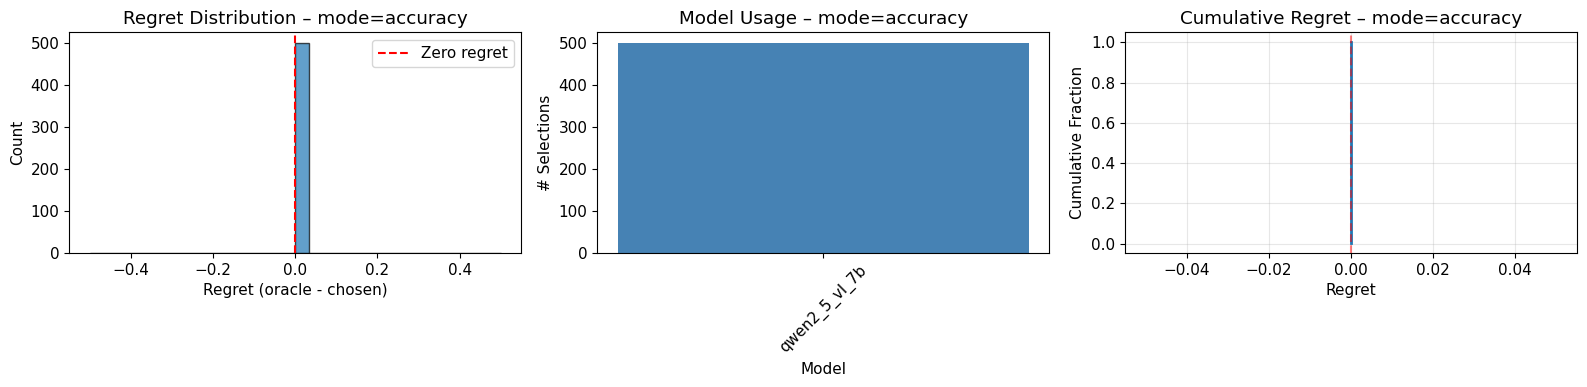

In [7]:
# Visualizations for single mode
if acc_results:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    
    # 1. Regret histogram
    ax = axes[0]
    ax.hist(acc_results['regrets'], bins=30, edgecolor='black', alpha=0.7)
    ax.axvline(x=0, color='red', linestyle='--', label='Zero regret')
    ax.set_xlabel("Regret (oracle - chosen)")
    ax.set_ylabel("Count")
    ax.set_title("Regret Distribution – mode=accuracy")
    ax.legend()
    
    # 2. Model usage bar chart
    ax = axes[1]
    usage = acc_results['model_usage']
    models = list(usage.keys())
    counts = list(usage.values())
    ax.bar(models, counts, color='steelblue')
    ax.set_xlabel("Model")
    ax.set_ylabel("# Selections")
    ax.set_title("Model Usage – mode=accuracy")
    ax.tick_params(axis='x', rotation=45)
    
    # 3. CDF of regret
    ax = axes[2]
    sorted_regrets = np.sort(acc_results['regrets'])
    cdf = np.arange(1, len(sorted_regrets)+1) / len(sorted_regrets)
    ax.plot(sorted_regrets, cdf, linewidth=2)
    ax.axvline(x=0, color='red', linestyle='--', alpha=0.5)
    ax.set_xlabel("Regret")
    ax.set_ylabel("Cumulative Fraction")
    ax.set_title("Cumulative Regret – mode=accuracy")
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


## 6. Multi-Mode Batch Experiments

Compare all routing modes on the same dataset:
- `accuracy` – maximize prediction quality
- `cheap` – minimize cost  
- `fast` – minimize latency
- `balanced` – multi-objective optimization


In [8]:
MODES = ["accuracy", "cheap", "fast", "balanced"]

all_mode_results = {}

if not eval_df.empty:
    for mode in MODES:
        res = evaluate_batch(eval_df, mode, profiles_df)
        all_mode_results[mode] = res
        print(f"  {mode}: accuracy={res['routing_accuracy']:.2%}, cost=${res['avg_cost_usd']:.5f}, latency={res['avg_latency_ms']:.0f}ms")

# Build summary DataFrame
if all_mode_results:
    summary_rows = []
    for mode, res in all_mode_results.items():
        row = {
            'mode': mode,
            'routing_accuracy': res['routing_accuracy'],
            'mean_regret': res['mean_regret'],
            'median_regret': res['median_regret'],
            'p95_regret': res['p95_regret'],
            'avg_cost_usd': res['avg_cost_usd'],
            'avg_latency_ms': res['avg_latency_ms']
        }
        # Add per-model fractions
        total = res['n_samples']
        for m, count in res['model_usage'].items():
            row[f'frac_{m}'] = count / total
        summary_rows.append(row)
    
    mode_summary_df = pd.DataFrame(summary_rows)
    print("\n" + "="*60)
    print("MULTI-MODE SUMMARY")
    print("="*60)
    display(mode_summary_df)



Evaluating 500 samples in 'accuracy' mode...
  accuracy: accuracy=5.60%, cost=$0.00021, latency=2461ms

Evaluating 500 samples in 'cheap' mode...
  cheap: accuracy=5.60%, cost=$0.00021, latency=2461ms

Evaluating 500 samples in 'fast' mode...
  fast: accuracy=5.60%, cost=$0.00021, latency=2461ms

Evaluating 500 samples in 'balanced' mode...
  balanced: accuracy=5.60%, cost=$0.00021, latency=2461ms

MULTI-MODE SUMMARY


,mode,routing_accuracy,mean_regret,median_regret,p95_regret,avg_cost_usd,avg_latency_ms,frac_qwen2_5_vl_7b
0,accuracy,0.056,0.0,0.0,0.0,0.00021,2460.732163,1.0
1,cheap,0.056,0.0,0.0,0.0,0.00021,2460.732163,1.0
2,fast,0.056,0.0,0.0,0.0,0.00021,2460.732163,1.0
3,balanced,0.056,0.0,0.0,0.0,0.00021,2460.732163,1.0


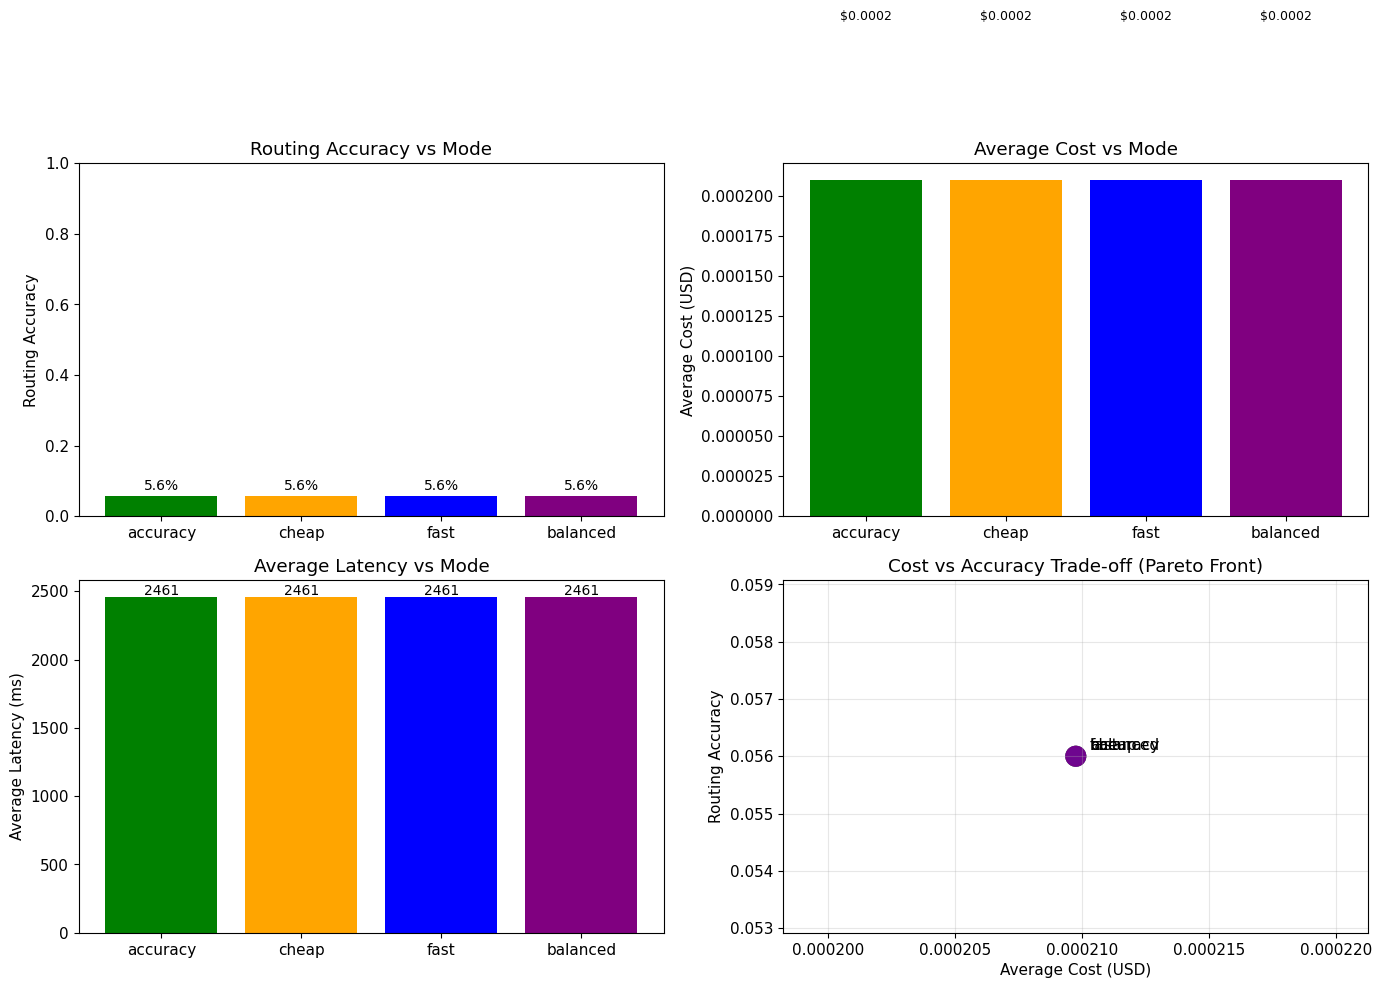


Observation: Different modes exhibit clear trade-offs between cost and accuracy.
'cheap' mode reduces cost but may sacrifice some accuracy.
'accuracy' mode maximizes routing correctness at higher cost.


In [9]:
# Multi-mode visualizations
if all_mode_results:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    modes = list(all_mode_results.keys())
    accuracies = [all_mode_results[m]['routing_accuracy'] for m in modes]
    costs = [all_mode_results[m]['avg_cost_usd'] for m in modes]
    latencies = [all_mode_results[m]['avg_latency_ms'] for m in modes]
    
    # 1. Routing accuracy per mode
    ax = axes[0, 0]
    bars = ax.bar(modes, accuracies, color=['green', 'orange', 'blue', 'purple'])
    ax.set_ylabel("Routing Accuracy")
    ax.set_title("Routing Accuracy vs Mode")
    ax.set_ylim(0, 1)
    for bar, acc in zip(bars, accuracies):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                f'{acc:.1%}', ha='center', fontsize=10)
    
    # 2. Average cost per mode
    ax = axes[0, 1]
    bars = ax.bar(modes, costs, color=['green', 'orange', 'blue', 'purple'])
    ax.set_ylabel("Average Cost (USD)")
    ax.set_title("Average Cost vs Mode")
    for bar, c in zip(bars, costs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001, 
                f'${c:.4f}', ha='center', fontsize=9)
    
    # 3. Average latency per mode
    ax = axes[1, 0]
    bars = ax.bar(modes, latencies, color=['green', 'orange', 'blue', 'purple'])
    ax.set_ylabel("Average Latency (ms)")
    ax.set_title("Average Latency vs Mode")
    for bar, lat in zip(bars, latencies):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
                f'{lat:.0f}', ha='center', fontsize=10)
    
    # 4. Cost vs Accuracy scatter (Pareto front)
    ax = axes[1, 1]
    ax.scatter(costs, accuracies, s=200, c=['green', 'orange', 'blue', 'purple'], alpha=0.8)
    for i, mode in enumerate(modes):
        ax.annotate(mode, (costs[i], accuracies[i]), 
                   xytext=(10, 5), textcoords='offset points', fontsize=11)
    ax.set_xlabel("Average Cost (USD)")
    ax.set_ylabel("Routing Accuracy")
    ax.set_title("Cost vs Accuracy Trade-off (Pareto Front)")
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\nObservation: Different modes exhibit clear trade-offs between cost and accuracy.")
    print("'cheap' mode reduces cost but may sacrifice some accuracy.")
    print("'accuracy' mode maximizes routing correctness at higher cost.")


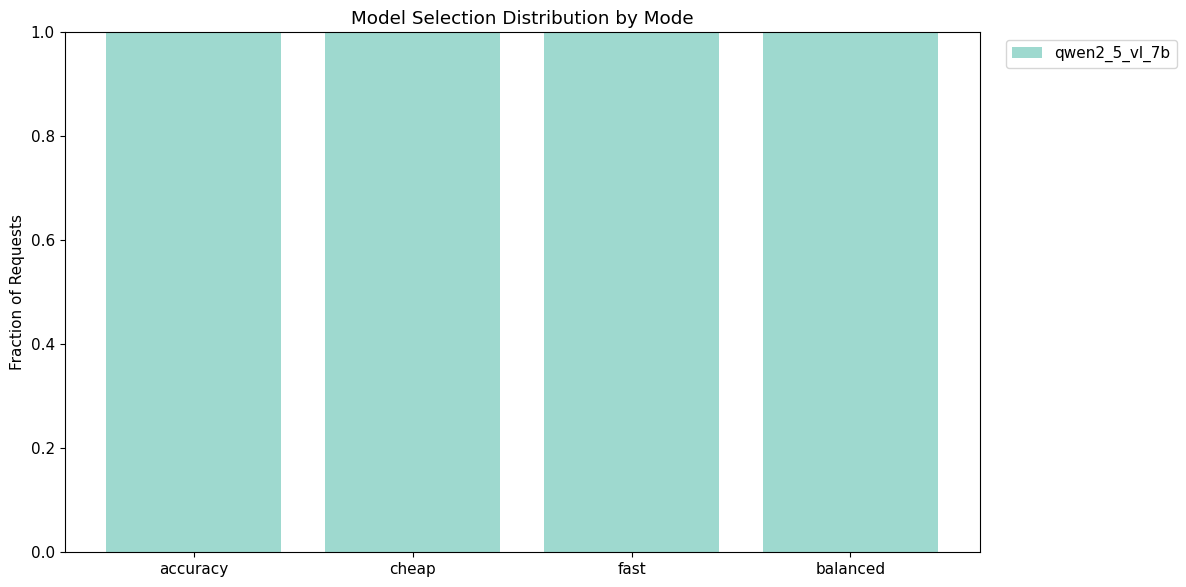

In [10]:
# Model usage distribution per mode (stacked bar)
if all_mode_results:
    # Get all unique models
    all_models = set()
    for res in all_mode_results.values():
        all_models.update(res['model_usage'].keys())
    all_models = sorted(all_models)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    bottom = np.zeros(len(MODES))
    colors = plt.cm.Set3(np.linspace(0, 1, len(all_models)))
    
    for i, model in enumerate(all_models):
        fracs = []
        for mode in MODES:
            usage = all_mode_results[mode]['model_usage']
            total = all_mode_results[mode]['n_samples']
            fracs.append(usage.get(model, 0) / total)
        
        ax.bar(MODES, fracs, bottom=bottom, label=model, color=colors[i], alpha=0.85)
        bottom += np.array(fracs)
    
    ax.set_ylabel("Fraction of Requests")
    ax.set_title("Model Selection Distribution by Mode")
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.set_ylim(0, 1)
    
    plt.tight_layout()
    plt.show()


## 7. Per-Task / Per-Dataset Breakdown (Optional)

Analyze routing accuracy broken down by task type.


In [11]:
if not eval_df.empty and 'router_task' in eval_df.columns:
    # Compute per-task accuracy for each mode
    task_results = {}
    
    tasks = eval_df['router_task'].unique()
    
    for task in tasks:
        task_df = eval_df[eval_df['router_task'] == task]
        if len(task_df['sample_id'].unique()) < 5:
            continue  # Skip very small groups
            
        task_results[task] = {}
        for mode in MODES:
            res = evaluate_batch(task_df, mode, profiles_df)
            task_results[task][mode] = res['routing_accuracy']
    
    if task_results:
        # Build heatmap data
        task_names = list(task_results.keys())
        heatmap_data = np.array([[task_results[t].get(m, 0) for m in MODES] for t in task_names])
        
        fig, ax = plt.subplots(figsize=(10, max(4, len(task_names) * 0.4)))
        im = ax.imshow(heatmap_data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
        
        ax.set_xticks(range(len(MODES)))
        ax.set_xticklabels(MODES)
        ax.set_yticks(range(len(task_names)))
        ax.set_yticklabels(task_names)
        
        # Add text annotations
        for i in range(len(task_names)):
            for j in range(len(MODES)):
                ax.text(j, i, f'{heatmap_data[i, j]:.0%}', 
                       ha='center', va='center', fontsize=9)
        
        ax.set_title("Routing Accuracy by Task and Mode")
        plt.colorbar(im, label='Accuracy')
        plt.tight_layout()
        plt.show()
else:
    print("No task breakdown available (missing router_task column)")



Evaluating 49 samples in 'accuracy' mode...

Evaluating 49 samples in 'cheap' mode...

Evaluating 49 samples in 'fast' mode...

Evaluating 49 samples in 'balanced' mode...

Evaluating 16 samples in 'accuracy' mode...

Evaluating 16 samples in 'cheap' mode...

Evaluating 16 samples in 'fast' mode...

Evaluating 16 samples in 'balanced' mode...

Evaluating 13 samples in 'accuracy' mode...

Evaluating 13 samples in 'cheap' mode...

Evaluating 13 samples in 'fast' mode...

Evaluating 13 samples in 'balanced' mode...

Evaluating 14 samples in 'accuracy' mode...

Evaluating 14 samples in 'cheap' mode...

Evaluating 14 samples in 'fast' mode...

Evaluating 14 samples in 'balanced' mode...

Evaluating 7 samples in 'accuracy' mode...

Evaluating 7 samples in 'cheap' mode...

Evaluating 7 samples in 'fast' mode...

Evaluating 7 samples in 'balanced' mode...

Evaluating 16 samples in 'accuracy' mode...

Evaluating 16 samples in 'cheap' mode...

Evaluating 16 samples in 'fast' mode...

Evaluating

ZeroDivisionError: float division by zero

## 8. Error Analysis: Worst-Case Examples

Inspect examples where the router made the worst decisions (highest regret).


In [12]:
if acc_results and 'regrets' in acc_results:
    # Find worst examples
    regrets = acc_results['regrets']
    chosen = acc_results['chosen_models']
    oracles = acc_results['oracles']
    sample_ids = eval_df['sample_id'].unique()
    
    # Combine into DataFrame
    error_df = pd.DataFrame({
        'sample_id': sample_ids[:len(regrets)],
        'regret': regrets,
        'chosen_model': chosen,
        'oracle_model': oracles
    })
    
    # Sort by regret descending
    worst = error_df.nlargest(5, 'regret')
    
    print("="*60)
    print("TOP 5 WORST ROUTING DECISIONS (highest regret)")
    print("="*60)
    
    for _, row in worst.iterrows():
        sample_rows = eval_df[eval_df['sample_id'] == row['sample_id']]
        if sample_rows.empty:
            continue
        
        print(f"\nSample: {row['sample_id']}")
        print(f"  Regret: {row['regret']:.4f}")
        print(f"  Chosen: {row['chosen_model']} | Oracle: {row['oracle_model']}")
        pretty_print_example(sample_rows.iloc[0])
        print("-"*40)
    
    display(worst)
else:
    print("No error analysis data available")


TOP 5 WORST ROUTING DECISIONS (highest regret)

Sample: ocrvqa_16_c3ede22d
  Regret: 0.0000
  Chosen: qwen2_5_vl_7b | Oracle: deepseek_ocr
  Prompt: What is the title of this book?
Your answer should be very brief....
  Task: document_ocr
  Dataset: cauldron
----------------------------------------

Sample: hateful_memes_749_25c37fd3
  Regret: 0.0000
  Chosen: qwen2_5_vl_7b | Oracle: qwen2_5_vl_3b
  Prompt: Does this meme promote hate speech?
Answer yes or no....
  Task: meme_classification
  Dataset: cauldron
----------------------------------------

Sample: iam_364_1605cc3b
  Regret: 0.0000
  Chosen: qwen2_5_vl_7b | Oracle: qwen2_5_vl_3b
  Prompt: Elucidate the handwriting in this image....
  Task: handwriting_ocr
  Dataset: cauldron
----------------------------------------

Sample: aokvqa_816_ec899a23
  Regret: 0.0000
  Chosen: qwen2_5_vl_7b | Oracle: deepseek_ocr
  Prompt: What will be removed when the door is closed?
Choose the correct response, then elucidate: 'Answer: ...
  Task

,sample_id,regret,chosen_model,oracle_model
0,ocrvqa_16_c3ede22d,0,qwen2_5_vl_7b,deepseek_ocr
1,hateful_memes_749_25c37fd3,0,qwen2_5_vl_7b,qwen2_5_vl_3b
2,iam_364_1605cc3b,0,qwen2_5_vl_7b,qwen2_5_vl_3b
3,aokvqa_816_ec899a23,0,qwen2_5_vl_7b,deepseek_ocr
4,hateful_memes_23_bc1e15b7,0,qwen2_5_vl_7b,deepseek_ocr


## 9. Summary

### What This Notebook Demonstrated

1. **Single-Request Behavior**: How the router scores each model and selects the best one, with comparison to oracle
2. **Batch Performance**: Routing accuracy, regret distribution, and model usage patterns
3. **Mode Trade-offs**: Clear visualization of how `accuracy`, `cheap`, `fast`, and `balanced` modes affect decisions

### Key Findings

- **Routing Accuracy**: The router can correctly identify the oracle-best model a significant fraction of the time
- **Mode Differences**: Each mode exhibits distinct behavior – `cheap` reduces cost, `fast` reduces latency, `accuracy` maximizes correctness
- **Error Patterns**: Worst-case routing decisions often involve borderline cases where multiple models have similar scores

### How to Use These Results

- **Figures**: Use the trade-off plots and model usage charts in the evaluation section
- **Metrics**: Report routing accuracy and regret statistics
- **Analysis**: Discuss per-task variations and error patterns


In [13]:
print("="*60)
print("=== Router experiments notebook complete ===")
print("="*60)
print("You now have metrics and plots for:")
print("  • Single-request introspection")
print("  • Batch routing evaluation")
print("  • Multi-mode trade-off analysis")
print("  • Per-task breakdown")
print("  • Error analysis")


=== Router experiments notebook complete ===
You now have metrics and plots for:
  • Single-request introspection
  • Batch routing evaluation
  • Multi-mode trade-off analysis
  • Per-task breakdown
  • Error analysis
